# Curve Preprocessing Walkthrough

Picks one real pixel from a POC_DDM_final experiment and tracks it through 01_curve_preprocessing_v6.py's real pipeline, using the exact same functions the pipeline uses (imported directly -- nothing reimplemented). X-axis is real experiment time throughout.

**Stages shown:**
1. Raw signal (pre-linearisation) -- captured via a hook into linearise.linearise(), since the pipeline never exposes this intermediate directly.
2. Linearised signal -- marked with where 01's truncation index (idx_settled + max_significant_index) and idx_end fall on this un-windowed timeline.
3. Truncated -- cropped to 01's max_significant_index, not yet rebaselined.
4. NC subtraction + rebaseline -- the real pipeline rebaselines (curve starts at 0) right after truncation, before NC subtraction, so this panel shows both applied together.
5. Denoising -- Savitzky-Golay filter, computed on the full batch (so its auto window-sweep sees a realistic sample size) and read back for our one pixel.

**To try a different sample:** change EXP_NAME / WELL_ID / PIXEL_SEED in the "Pick a sample" cell and re-run from there.


In [43]:
import os, sys, importlib.util, time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Run from main/ (matches house style -- 01_curve_preprocessing_v6.py's own
# sys.path.insert calls are CWD-relative, not __file__-relative).
try:
    _nb = globals().get('__vsc_ipynb_file__')
    if _nb:
        os.chdir(os.path.dirname(os.path.dirname(_nb)))
except Exception:
    pass
sys.path.insert(0, os.getcwd())
sys.path.insert(0, 'utils')

%load_ext autoreload
%autoreload 2

# 01_curve_preprocessing_v6.py can't be `import`ed (starts with a digit) -- load it as
# a module directly, mirroring ablation_significance_analysis.ipynb's pattern for
# 08_statistical_comparison.py. exec_module runs with __name__ != '__main__', so the
# CLI/argparse block at the bottom never executes -- only the reusable functions do.
_spec = importlib.util.spec_from_file_location(
    "curve_preprocessing_v6", str(Path.cwd() / "01_curve_preprocessing_v6.py"))
cp01 = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(cp01)
config = cp01.config

# cp01's own top-level imports (chip_v6_utils -> titan_v6/__init__ path insert) put
# titan_v6 on sys.path as a side effect, so this now resolves.
import linearise as linearise_mod

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.color': '#e0e0e0',
    'grid.linestyle': '--',
    'grid.alpha': 0.7,
    'font.size': 10,
})
print("CWD:", os.getcwd())
print("Available POC_DDM_final experiments:",
      sorted(p.name for p in Path(config.FINAL_EXP_FOLDER).iterdir() if p.is_dir()))


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
CWD: /vol/bitbucket/gk225/POC_DDM/gk_code/main
Available POC_DDM_final experiments: ['D20260806_E00_C00_F4500KHz_U_DDM_01_06', 'D20260807_E00_C00_F4500KHz_U_DDM_02_07', 'D20260808_E00_C00_F4500KHz_U_DDM_03_01', 'D20260810_E00_C00_F4500KHz_U_DDM_04_01']


## Pick a sample -- change these and re-run from here

In [ ]:
EXP_NAME = 'D20260807_E00_C00_F4500KHz_U_DDM_02_07'  # any name from the list printed above
WELL_ID = 6           # 0..9 (config.N_WELLS=10 wells per experiment)
exp_path = Path(config.FINAL_EXP_FOLDER) / EXP_NAME


## Load + capture the raw (pre-linearisation) signal

`linearise.linearise(frame_3d, params, idx_active_gain)` is where the raw ADC-ish signal
becomes the linearised chemical signal (see `titan_v6/linearise.py`). The pipeline only
ever keeps the *output* on the `Well` object, so we hook the function to also record its
*input* for the one call this experiment makes.

In [80]:
_captured = []
_orig_linearise = linearise_mod.linearise
def _hooked_linearise(frame_3d, *args, **kwargs):
    raw_in = frame_3d.copy()
    out = _orig_linearise(frame_3d, *args, **kwargs)
    lin_out = out[0].copy() if isinstance(out, tuple) else out.copy()
    _captured.append((raw_in, lin_out))
    return out
linearise_mod.linearise = _hooked_linearise

t0 = time.perf_counter()
all_exp_data = cp01.load_and_preprocess_v6(
    exp_path, n_wells=config.N_WELLS, n_a_type=config.N_A_TYPE, vref_ref_idx='all')
linearise_mod.linearise = _orig_linearise  # unhook, one-shot capture is enough
print(f"\nLoaded in {time.perf_counter() - t0:.1f}s -- {len(all_exp_data)} vref slice(s), "
      f"{len(all_exp_data[0].wells_list)} wells")

raw_full, lin_full = _captured[0]  # full-chip (rows, cols, time), before the well split


[INFO] D20260807_E00_C00_F4500KHz_U_DDM_02_07: found 1 readout file(s). Processing...
Loaded vref sweep from 20260807T131525.38_vref_sweep.bin: n_vrefs=1
[INFO] Slice 1/1: DDM_02_07__vref_idx=0_vref=2730
EXP PATH /vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final/D20260807_E00_C00_F4500KHz_U_DDM_02_07 
VREF PATH /vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final/D20260807_E00_C00_F4500KHz_U_DDM_02_07/20260807T131525.38_vref_sweep.bin 
Load vref... 
Loaded vref list: n_vrefs=1, first=2730, last=2730
EXP PATH /vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final/D20260807_E00_C00_F4500KHz_U_DDM_02_07 
READOUT PATH /vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final/D20260807_E00_C00_F4500KHz_U_DDM_02_07/20260807T131602.84_readout_time.bin 
Load data... 
(290, 204, 1, 874)
Time vector: n=874, median_dt=3s, duration≈41.48min
(59160,)
new gain shape  (59160,)
(290, 204, 1, 874)
Data loaded. 
Preprocessing start...
Active pixel counts (ref_idx=0, vref=2730.0): lacewing=19808, non_temp=56782,

## Locate our pixel in the full-chip array

`preprocess.split_wells` splits the full chip into a `(n_wells//2, 2)` grid of equal
row/col blocks (verified directly: `well.well_3d_lin[local_r, local_c, :]` exactly
matches `lin_full[global_r, global_c, :]` under this mapping). This lets us track one
*real* physical pixel continuously from the raw signal all the way through.

In [ ]:
well = all_exp_data[0].wells_list[WELL_ID]
local_rows, local_cols = well.well_3d_lin.shape[0], well.well_3d_lin.shape[1]

idx_active = np.asarray(well.idx_active)
active_positions = np.where(idx_active)[0]


well=6  local pixel=(43,49)  global pixel=(217,49)


In [143]:
PIXEL_SEED = 120        # picks a random *active* pixel within that well; change for a different curve
rng = np.random.default_rng(PIXEL_SEED)
pick_flat = int(rng.choice(active_positions))
local_r, local_c = np.unravel_index(pick_flat, (local_rows, local_cols), order='C')

row_group, col_group = WELL_ID // 2, WELL_ID % 2
global_r = row_group * local_rows + local_r
global_c = col_group * local_cols + local_c
print(f"well={WELL_ID}  local pixel=({local_r},{local_c})  global pixel=({global_r},{global_c})")


well=6  local pixel=(26,27)  global pixel=(200,27)


## Reconstruct the full batch + find 01's truncation index (MSI)

Both need the *whole* experiment's active-pixel curves, not just our one pixel -- the
same array `01_curve_preprocessing_v6.py`'s main block works with, so the truncation
index is computed exactly the way the real pipeline computes it.

In [144]:
X_time, Y_well, X_2d_bs_active = cp01.reconstruct_data(all_exp_data, attr_str="well_2d_bs_active")

# Row index of our pixel within the reconstructed batch: reconstruct_data iterates
# wells in order, each contributing its active pixels in idx_active's True-position
# order -- so it's (# active pixels in earlier wells) + (# active pixels before ours
# within this well).
active_rank = int(np.sum(idx_active[:pick_flat]))
offset = sum(int(np.sum(all_exp_data[0].wells_list[i].idx_active)) for i in range(WELL_ID))
row_idx = offset + active_rank
assert np.allclose(X_2d_bs_active[row_idx], well.well_2d_bs_active[:, np.sum(idx_active[:pick_flat])]), \
    "pixel row mapping is wrong -- fix before trusting downstream steps"
print(f"X_2d_bs_active shape: {X_2d_bs_active.shape}  (our pixel is row {row_idx})")


X_2d_bs_active shape: (17234, 842)  (our pixel is row 10497)


In [145]:
from scipy.ndimage import uniform_filter1d

mapping = config.LABEL_MAPPINGS.get(EXP_NAME)
y_label = np.array([mapping.get(w, w) for w in Y_well]) if mapping is not None else None
pc_mask = (y_label == 'PC') if y_label is not None else np.zeros(len(Y_well), dtype=bool)

if np.any(pc_mask):
    smoothed = uniform_filter1d(np.mean(X_2d_bs_active[pc_mask], axis=0).squeeze(), size=20)
    max_significant_index = int(np.argmin(smoothed))
    print(f"[PC argmin] max_significant_index={max_significant_index} ({int(pc_mask.sum())} PC-well curves)")
else:
    ori_curve_dydx = np.array(cp01.get_derivatives(X_2d_bs_active, X_time))
    min_indices = np.argmin(ori_curve_dydx, axis=1)
    unique_indices, counts = np.unique(min_indices, return_counts=True)
    significant_indices = unique_indices[counts > (len(ori_curve_dydx) / 3)]
    max_significant_index = int(np.max(significant_indices)) if len(significant_indices) > 0 else None
    print(f"[Derivative vote] max_significant_index={max_significant_index}")


[PC argmin] max_significant_index=14 (1814 PC-well curves)


## 1-2. Raw and linearised

X-axis is real experiment time throughout (`well.time_npr`, seconds) so every panel is
directly comparable. The linearised panel marks where `01`'s truncation index sits on
this un-windowed timeline (`idx_settled + max_significant_index`) and where `idx_end`
is -- both computed on the *full* raw/linearised signal, not the truncated one, since
that's the only timeline this panel can show.

In [146]:
t_full = well.time_npr  # full, un-windowed experiment time axis (seconds)

steps = []  # list of (title, x, y) -- built up one stage at a time
steps.append(("1. Raw Signal", t_full, raw_full[global_r, global_c, :]))
steps.append(("2. Linearised", t_full, lin_full[global_r, global_c, :]))

msi_time = t_full[well.idx_settled + max_significant_index]
idx_end_time = t_full[min(well.idx_end, len(t_full) - 1)]
print(f"MSI marker at t={msi_time:.1f}s (idx_settled={well.idx_settled} + MSI={max_significant_index})")
print(f"idx_end marker at t={idx_end_time:.1f}s (idx_end={well.idx_end})")


MSI marker at t=127.0s (idx_settled=31 + MSI=14)
idx_end marker at t=2489.0s (idx_end=873)


## 3. Truncated

Cropped to `01`'s `max_significant_index`, not yet rebaselined -- the rebaseline
(`X_2d_bs_active = truncated_curves - truncated_curves[:, 0:1]`) happens next, together
with NC subtraction, matching the real pipeline's order (rebaseline right after
truncation, before NC subtraction).

In [147]:
X_2d_trunc, t_trunc = X_2d_bs_active, t_full[well.idx_settled:well.idx_end]
if max_significant_index is not None and (max_significant_index + 1) < (len(X_time) - 100):
    X_2d_trunc = X_2d_bs_active[:, max_significant_index + 1:]
    t_trunc = t_trunc[max_significant_index + 1:]
t_trunc = t_trunc - t_trunc[0]  # matches 01's own post-truncation timestamp reset

steps.append(("3. Truncated", t_trunc, X_2d_trunc[row_idx]))
print("Truncated shape:", X_2d_trunc.shape)


Truncated shape: (17234, 827)


## 4. NC subtraction + rebaseline

In [148]:
X_2d_trunc = X_2d_trunc - X_2d_trunc[:, 0:1]  # rebaseline -- real pipeline does this right after truncation, before NC subtraction

pixel_temp_dfs = cp01.extract_pixel_temp_dataframes(all_exp_data)
vref_idx_all = pixel_temp_dfs["well_2d_bs_active_df"]['vref_idx'].values

X_2d_nc = X_2d_trunc.copy()
if mapping is None:
    print("[!] No config.LABEL_MAPPINGS for this experiment -- NC subtraction skipped "
          "(same as 01 without --nc_subtract would do for an unmapped dataset).")
else:
    unique_vrefs = np.unique(vref_idx_all)
    unique_labels = np.unique(y_label)
    if 'NC-ALL' in unique_labels:
        for vref_val in unique_vrefs:
            vref_mask = (vref_idx_all == vref_val)
            nc_all_mask = vref_mask & (y_label == 'NC-ALL')
            if np.any(nc_all_mask):
                nc_baseline = np.mean(X_2d_trunc[nc_all_mask], axis=0)
                X_2d_nc[vref_mask] = X_2d_trunc[vref_mask] - nc_baseline
        print("Applied universal 'NC-ALL' subtraction.")
    else:
        base_labels = list(dict.fromkeys([str(lbl).replace('NC-', '') for lbl in unique_labels]))
        applied = []
        for vref_val in unique_vrefs:
            vref_mask = (vref_idx_all == vref_val)
            for b_lbl in base_labels:
                nc_target = f"NC-{b_lbl}"
                if b_lbl in unique_labels and nc_target in unique_labels:
                    nc_mask = vref_mask & (y_label == nc_target)
                    sample_mask = vref_mask & (y_label == b_lbl)
                    if np.any(nc_mask) and np.any(sample_mask):
                        nc_baseline = np.mean(X_2d_trunc[nc_mask], axis=0)
                        X_2d_nc[sample_mask] = X_2d_trunc[sample_mask] - nc_baseline
                        X_2d_nc[nc_mask] = X_2d_trunc[nc_mask] - nc_baseline
                        applied.append(f"{nc_target}->{b_lbl}")
        print("Applied per-label NC subtraction:", applied or "(no matching NC/label pairs found)")

steps.append(("4. Negative Control Subtracted", t_trunc, X_2d_nc[row_idx]))


Applied universal 'NC-ALL' subtraction.


## 5. Denoising -- Savitzky-Golay Filter

In [149]:
t0 = time.perf_counter()
sg_curves, opt_w = cp01.sg_p4_denoise_curves(X_2d_nc)
steps.append((f"5. Denoising - Savitzky-Golay Filter", t_trunc, sg_curves[row_idx]))
print(f"SG denoise done in {time.perf_counter() - t0:.1f}s")


SG denoise done in 4.0s


## Plot every stage

D20260807_E00_C00_F4500KHz_U_DDM_02_07  |  well 6  |  pixel (local 26,27 / global 200,27)


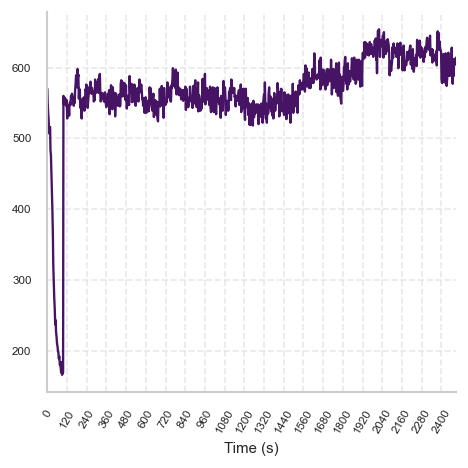

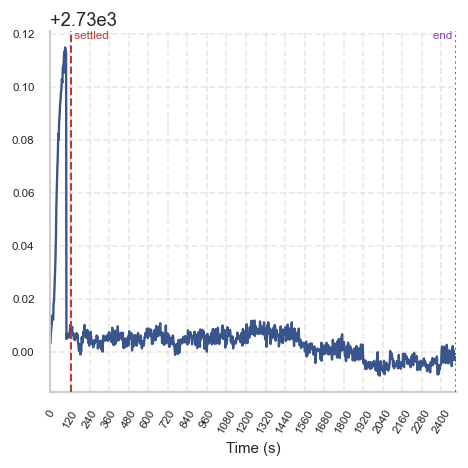

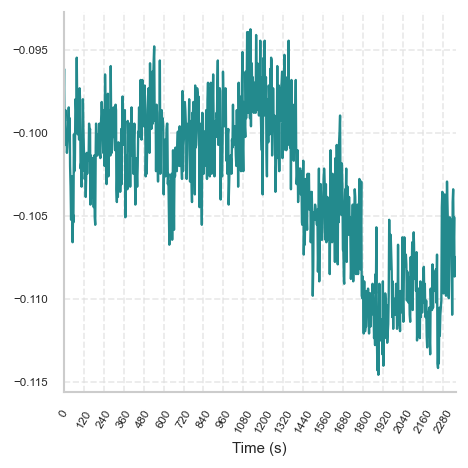

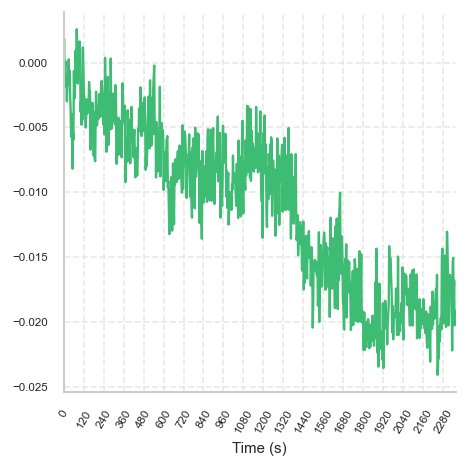

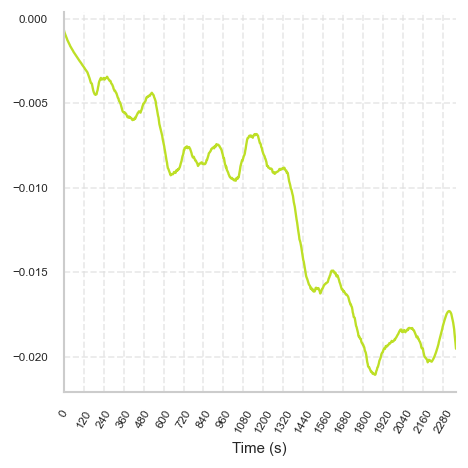

In [150]:
from matplotlib.ticker import MultipleLocator

print(f"{EXP_NAME}  |  well {WELL_ID}  |  pixel (local {local_r},{local_c} / "
      f"global {global_r},{global_c})")

colors = plt.cm.viridis(np.linspace(0.05, 0.9, len(steps)))

for i, ((title, x, y), color) in enumerate(zip(steps, colors)):
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.plot(x, y, color=color, lw=1.4)
    # ax.set_title(title, fontsize=10.5, fontweight='bold', loc='left')
    ax.set_xlim(x[0], x[-1])
    ax.set_xlabel("Time (s)", fontsize=9)
    ax.tick_params(labelsize=7)
    ax.tick_params(axis='x', rotation=60)
    ax.xaxis.set_major_locator(MultipleLocator(120))
    if i == 1:  # linearised panel -- mark where MSI truncation and idx_end fall
        ylim = ax.get_ylim()
        ax.axvline(msi_time, color='#c0392b', lw=1.2, linestyle='--', zorder=5)
        ax.axvline(idx_end_time, color='#8e44ad', lw=1.2, linestyle=':', zorder=5)
        ax.text(msi_time, ylim[1], ' settled', color='#c0392b', fontsize=7, va='top', ha='left')
        ax.text(idx_end_time, ylim[1], 'end ', color='#8e44ad', fontsize=7, va='top', ha='right')
    fig.tight_layout()
    plt.show()
